In [101]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("prathamtripathi/drug-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'drug-classification' dataset.
Path to dataset files: /kaggle/input/drug-classification


In [102]:
import pandas as pd
import os

# Assuming the dataset contains a CSV file, let's find it.
# The 'path' variable from the previous cell should point to a directory.
# We can list the contents of that directory to find the CSV file.

dataset_files = os.listdir(path)
csv_file = None
for file in dataset_files:
    if file.endswith('.csv'):
        csv_file = os.path.join(path, file)
        break

if csv_file:
    df = pd.read_csv(csv_file)
    print(f"Successfully loaded data from: {csv_file}")
    display(df.head())
else:
    print("No CSV file found in the downloaded dataset.")

Successfully loaded data from: /kaggle/input/drug-classification/drug200.csv


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


### Basic Exploratory Data Analysis (EDA)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [104]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [105]:
df['Drug'].value_counts()

,count
Drug,
DrugY,91
drugX,54
drugA,23
drugC,16
drugB,16


<Axes: xlabel='Drug', ylabel='count'>

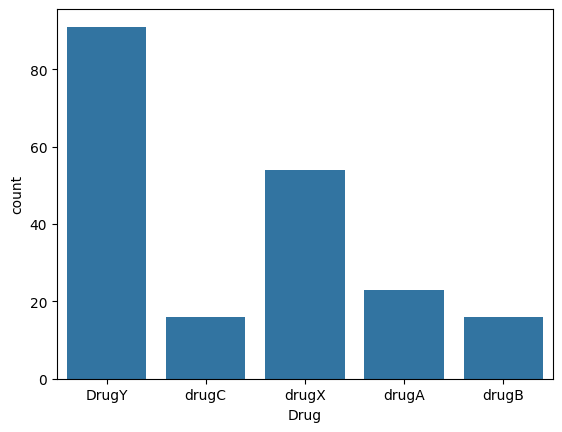

In [106]:
sns.countplot(x='Drug', data=df)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [108]:
#Skewness
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [109]:
skewed_data = df[num_cols].skew()

In [110]:
#1. Numerical column in which we have to apply skewness transformation.(iss column pr -> skewness transformation, StandardScaler)
skewed_numerical_feature = skewed_data[skewed_data > 0.5].index.tolist()

#2. Column that is not going to be processed for skewness transformation (ispe sirf standardscaler)
other_numerical_feature = skewed_data[skewed_data <= 0.5].index.tolist()

#3. Object columns but without 'Drug' because that is our Target column.
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
categorical_features.remove('Drug')

In [111]:
skewed_numerical_features

['Na_to_K']

In [112]:
other_numerical_features

['Age']

In [113]:
categorical_features

['Sex', 'BP', 'Cholesterol']

#Building Piplelines for our 3 columns

**1. Skewed Features (1. Skewness Transformation, 2. StandardScaler)**    
**2. Other numerical features(1. StandardScaler)**     
**3. Categorical Features (1.OneHotEncoding)**

In [114]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [115]:
#1. Pipeline for Skewed Features
skewed_transformer = Pipeline(steps=[
    ('power_transform', PowerTransformer()),
    ('standard_scaler', StandardScaler())
])

other_numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('one_hot', OneHotEncoder(handle_unknown='ignore')) # Added handle_unknown to prevent errors with unseen categories
])

preprocessor = ColumnTransformer(
    transformers=[
        ('Skewed_num', skewed_transformer, skewed_numerical_feature),
        ('other_num', other_numerical_transformer, other_numerical_feature),
        ('categorical', categorical_transformer, categorical_features) # Ensure categorical_features (list of strings) is used here
    ],
    remainder='passthrough' # Keep any columns not explicitly transformed
)

In [116]:
X = df.drop('Drug', axis=1)
y = df['Drug']

In [117]:
preprocessor

ColumnTransformer(transformers=[('Skewed_num',
                                 Pipeline(steps=[('power_transform',
                                                  PowerTransformer()),
                                                 ('standard_scaler',
                                                  StandardScaler())]),
                                 ['Na_to_K']),
                                ('other_num',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Age']),
                                ('categorical',
                                 Pipeline(steps=[('one_hot', OneHotEncoder())]),
                                 ['Sex', 'BP', 'Cholesterol'])])

In [120]:
X_transformed = preprocessor.fit_transform(X)

array([[ 1.27076331, -1.29159102,  1.        , ...,  0.        ,
         1.        ,  0.        ],
       [-0.20895238,  0.16269866,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       [-0.8851916 ,  0.16269866,  0.        , ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-0.94539752,  0.46567567,  0.        , ...,  1.        ,
         1.        ,  0.        ],
       [-0.03918172, -1.29159102,  0.        , ...,  1.        ,
         0.        ,  1.        ],
       [-0.57645012, -0.26146916,  1.        , ...,  0.        ,
         0.        ,  1.        ]])